# Coin Flip Trading System

Uses a coin flip based trading strategy (heads = long, tails = short) to make trading decisions at market open while leveraging timeseries forcasting

## Module.1
### dependencies

In [21]:
# cellblock.1

# libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import yfinance as yf
import math
import re

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

In [22]:
# cellblock.2

# import local data
file_path = "/Users/andrew/main/trading/data/NQ.1m.OHLCV.data/NQ-2010.06.06-2026.01.23-ohlcv-1m.csv"
df = pd.read_csv(file_path)

print(df.head())


                         ts_event  rtype  publisher_id  instrument_id     open     high      low    close  volume symbol
0  2010-06-06T22:00:00.000000000Z     33             1           6641  1831.75  1831.75  1828.75  1829.00     117   NQM0
1  2010-06-06T22:00:00.000000000Z     33             1          26715  1833.50  1833.50  1827.75  1827.75       3   NQU0
2  2010-06-06T22:01:00.000000000Z     33             1           6641  1828.50  1831.00  1828.50  1830.50      99   NQM0
3  2010-06-06T22:02:00.000000000Z     33             1           6641  1830.50  1832.25  1830.50  1831.25      32   NQM0
4  2010-06-06T22:03:00.000000000Z     33             1          26715  1828.00  1828.00  1828.00  1828.00       1   NQU0


In [23]:
# cellblock.3

# load yfinance data
YF_PERIOD   = "60d"
YF_INTERVAL = "15m"
OHLCV = ["open", "high", "low", "close", "volume"]


def fetch_15m(ticker, label, period=YF_PERIOD):
    """Download max-available 15m bars and return a clean OHLCV frame.

    Returns all five OHLCV columns; index is tz-aware and sorted ascending.
    """
    raw = yf.download(ticker, period=period, interval=YF_INTERVAL,
                      auto_adjust=False, progress=False, threads=False)
    if raw is None or len(raw) == 0:
        raise RuntimeError(f"{label} ({ticker}): yfinance returned no rows")

    # yfinance returns MultiIndex columns (field, ticker) -> flatten to field
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(-1)

    df = raw.rename(columns=str.lower)
    missing = [c for c in OHLCV if c not in df.columns]
    if missing:
        raise RuntimeError(f"{label} ({ticker}): missing columns {missing}")

    df = df[OHLCV].copy()
    df = df[~df.index.duplicated(keep="last")].sort_index()
    df = df.dropna(subset=["open", "high", "low", "close"])
    df["volume"] = df["volume"].fillna(0)
    df.index.name = "ts"
    df.columns.name = None
    return df


def describe_15m(df, label, ticker):
    """Print coverage + integrity checks. Returns the frame unchanged."""
    span_days = (df.index[-1] - df.index[0]).total_seconds() / 86400
    bad_hl = int((df["high"] < df["low"]).sum())
    bad_rng = int((~((df["high"] >= df[["open", "close"]].max(axis=1) - 1e-6) &
                     (df["low"]  <= df[["open", "close"]].min(axis=1) + 1e-6))).sum())
    gap = df.index.to_series().diff().dt.total_seconds().div(60)
    print(f"{label}  ({ticker})  interval=15m")
    print(f"  bars      : {len(df):,}")
    print(f"  coverage  : {df.index[0]}  ->  {df.index[-1]}   ({span_days:.1f} calendar days)")
    print(f"  columns   : {list(df.columns)}")
    print(f"  close     : {df['close'].min():,.2f}  -  {df['close'].max():,.2f}")
    print(f"  volume    : total {df['volume'].sum():,.0f}"
          + ("   [!] all-zero: Yahoo reports no volume for this symbol"
             if df["volume"].sum() == 0 else ""))
    print(f"  integrity : high<low {bad_hl} | OHLC out of range {bad_rng} | NaN {int(df.isna().sum().sum())}")
    print(f"  bar gaps  : median {gap.median():.0f}m, max {gap.max():,.0f}m "
          f"(>15m gaps are session breaks/weekends)")
    return df


def plot_ohlcv(df, label, ticker, interval="15m", bar_minutes=15, downsampled=False):
    """Two-panel OHLCV chart: high-low range + close on top, volume beneath."""
    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(13, 6.5),
        gridspec_kw={"height_ratios": [3, 1]})

    ax1.fill_between(df.index, df["low"], df["high"], color="#4a7ebb",
                     alpha=0.30, linewidth=0, label="High-Low range")
    ax1.plot(df.index, df["close"], color="#14375e", linewidth=0.8, label="Close")
    ax1.plot(df.index, df["open"],  color="#c0504d", linewidth=0.5,
             alpha=0.55, label="Open")
    ax1.set_ylabel("Price")
    ax1.set_title(f"{label}  ({ticker})  -  {interval} OHLCV"
                  + ("  [chart downsampled]" if downsampled else "")
                  + f"  |  {len(df):,} bars  |  "
                  f"{df.index[0]:%Y-%m-%d} to {df.index[-1]:%Y-%m-%d}")
    ax1.legend(loc="upper left", fontsize=8, framealpha=0.9)

    width = bar_minutes / (24 * 60) * 0.9
    ax2.bar(df.index, df["volume"], width=width, color="#7f7f7f", linewidth=0)
    ax2.set_ylabel("Volume")
    ax2.set_xlabel("Time")
    if df["volume"].sum() == 0:
        ax2.text(0.5, 0.5, "no volume reported by source", ha="center",
                 va="center", transform=ax2.transAxes, fontsize=9, color="#c0504d")
    fig.autofmt_xdate()
    fig.subplots_adjust(hspace=0.08)
    plt.show()


def load_plot_15m(ticker, label):
    """Fetch -> validate -> chart. Returns the full 15m OHLCV frame."""
    df = fetch_15m(ticker, label)
    describe_15m(df, label, ticker)
    plot_ohlcv(df, label, ticker)
    return df

## Module.2
### load assets
**BTC, /ES, /NQ, /RTY, /YM, ETH, AAPL, NVDA, TSLA, VIX**

| cellblock | asset | source | interval | variable |
|---|---|---|---|---|
| 1 | /NQ | local CSV (front-month continuous) | **1m** | `nq_1m` |
| 2 | /NQ | yfinance `NQ=F` | 15m | `nq_15m` |
| 3 | /ES | yfinance `ES=F` | 15m | `es_15m` |
| 4 | /RTY | yfinance `RTY=F` | 15m | `rty_15m` |
| 5 | /YM | yfinance `YM=F` | 15m | `ym_15m` |
| 6 | BTC | yfinance `BTC-USD` | 15m | `btc_15m` |
| 7 | ETH | yfinance `ETH-USD` | 15m | `eth_15m` |
| 8 | TSLA | yfinance `TSLA` | 15m | `tsla_15m` |
| 9 | NVDA | yfinance `NVDA` | 15m | `nvda_15m` |
| 10 | AAPL | yfinance `AAPL` | 15m | `aapl_15m` |
| 11 | VIX | yfinance `^VIX` | 15m | `vix_15m` |

Every frame carries the full `open, high, low, close, volume` set. Yahoo caps 15m
intraday history at ~60 days, so `period="60d"` is the maximum obtainable; realised
coverage varies by asset (crypto 24/7 > futures ~23h > equities RTH only).

rows: 6,949,239 total -> 6,449,662 outright (499,577 spread rows dropped, 7.19%)
distinct contracts (by instrument_id): 69
days where raw volume leader moved backwards: 0
roll events: 64  (expect ~4/yr over 15.6 yrs)

/NQ continuous front-month, 1m OHLCV
  bars      : 5,288,241
  coverage  : 2010-06-06 22:00:00+00:00  ->  2026-01-23 21:59:00+00:00
  columns   : ['open', 'high', 'low', 'close', 'volume', 'symbol']
  close     : 1,699.25  -  26,396.25
  duplicate timestamps : 0
  OHLC out of range    : 0
  max |1m log return|  : 0.0454   (roll gaps are NOT price-adjusted -- see note below)
                              open     high      low    close  volume symbol
ts                                                                          
2010-06-06 22:00:00+00:00  1831.75  1831.75  1828.75  1829.00     117   NQM0
2010-06-06 22:01:00+00:00  1828.50  1831.00  1828.50  1830.50      99   NQM0
2010-06-06 22:02:00+00:00  1830.50  1832.25  1830.50  1831.25      32   NQM0
2010-06-06 22:03:00+

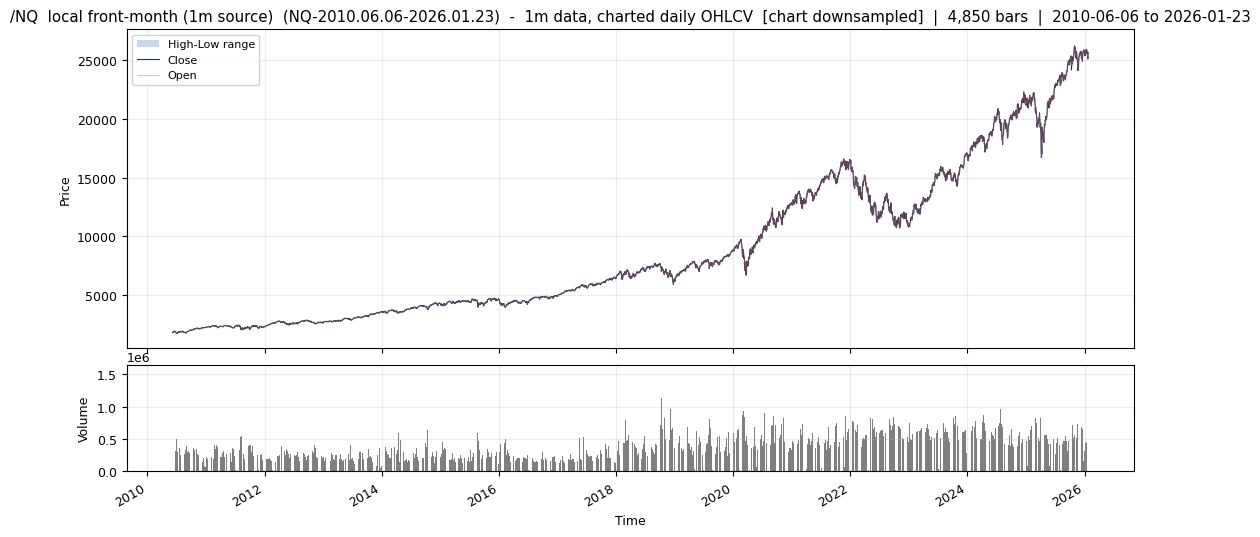

In [24]:
# cellblock.1

# /NQ local data (1m)
OUTRIGHT = re.compile(r"^NQ[HMUZ]\d$")          # NQ + month code + year digit
NQ_COLS  = ["ts_event", "instrument_id", "open", "high", "low", "close", "volume", "symbol"]

nq_raw = pd.read_csv(
    file_path, usecols=NQ_COLS, engine="pyarrow",
    dtype={"instrument_id": "int64", "open": "float32", "high": "float32",
           "low": "float32", "close": "float32", "volume": "int32",
           "symbol": "category"})

n_all = len(nq_raw)
nq_raw = nq_raw[nq_raw["symbol"].astype(str).str.fullmatch(OUTRIGHT)].copy()
print(f"rows: {n_all:,} total -> {len(nq_raw):,} outright "
      f"({n_all - len(nq_raw):,} spread rows dropped, {100*(n_all-len(nq_raw))/n_all:.2f}%)")

nq_raw["ts_event"] = pd.to_datetime(nq_raw["ts_event"], utc=True, format="ISO8601")
nq_raw["date"] = nq_raw["ts_event"].dt.date

# expiry order: each instrument_id is one real contract, so its last bar orders it
expiry_rank = {cid: k for k, cid in enumerate(
    nq_raw.groupby("instrument_id", observed=True)["ts_event"].max().sort_values().index)}
rank_to_id = {k: cid for cid, k in expiry_rank.items()}
print(f"distinct contracts (by instrument_id): {len(expiry_rank)}")

# front month = highest daily volume, constrained to never roll backwards
daily_vol = (nq_raw.groupby(["date", "instrument_id"], observed=True)["volume"]
                   .sum().reset_index())
front = (daily_vol.loc[daily_vol.groupby("date", observed=True)["volume"].idxmax(),
                       ["date", "instrument_id"]]
                  .rename(columns={"instrument_id": "front"})
                  .sort_values("date").reset_index(drop=True))
front["rank"] = front["front"].map(expiry_rank).astype(int)
front["rank_fwd"] = front["rank"].cummax()
print(f"days where raw volume leader moved backwards: {(front['rank'] != front['rank_fwd']).sum()}")
front["front_id"] = front["rank_fwd"].map(rank_to_id)
roll_dates = front.loc[front["front_id"] != front["front_id"].shift(), "date"].tolist()
print(f"roll events: {len(roll_dates)}  (expect ~4/yr over "
      f"{(nq_raw['ts_event'].max() - nq_raw['ts_event'].min()).days/365.25:.1f} yrs)")

# keep only bars belonging to that day's front contract -> continuous 1m OHLCV
nq_1m = (nq_raw.merge(front[["date", "front_id"]], on="date", how="left")
               .query("instrument_id == front_id")
               .sort_values("ts_event")
               .set_index("ts_event")[["open", "high", "low", "close", "volume", "symbol"]])
nq_1m.index.name = "ts"

# ---- integrity checks -------------------------------------------------------
logret = np.log(nq_1m["close"].astype("float64")).diff()
print(f"\n/NQ continuous front-month, 1m OHLCV")
print(f"  bars      : {len(nq_1m):,}")
print(f"  coverage  : {nq_1m.index[0]}  ->  {nq_1m.index[-1]}")
print(f"  columns   : {list(nq_1m.columns)}")
print(f"  close     : {nq_1m['close'].min():,.2f}  -  {nq_1m['close'].max():,.2f}")
print(f"  duplicate timestamps : {int(nq_1m.index.duplicated().sum())}")
ohlc_bad = int((~((nq_1m["high"] >= nq_1m[["open", "close"]].max(axis=1) - 1e-6) &
                  (nq_1m["low"] <= nq_1m[["open", "close"]].min(axis=1) + 1e-6))).sum())
print(f"  OHLC out of range    : {ohlc_bad}")
print(f"  max |1m log return|  : {logret.abs().max():.4f}"
      "   (roll gaps are NOT price-adjusted -- see note below)")
print(nq_1m.head())

# ---- chart ------------------------------------------------------------------
# 5.3M 1-minute points cannot be rendered legibly, so the CHART aggregates to
# daily bars. `nq_1m` itself keeps every 1-minute bar.
nq_daily = nq_1m.resample("1D").agg(
    {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
).dropna(subset=["close"])
plot_ohlcv(nq_daily, "/NQ  local front-month (1m source)", "NQ-2010.06.06-2026.01.23",
           interval="1m data, charted daily", bar_minutes=60*24, downsampled=True)

/NQ  (NQ=F)  interval=15m
  bars      : 4,476
  coverage  : 2026-07-09 00:00:00-04:00  ->  2026-09-17 01:00:00-04:00   (70.0 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 27,242.25  -  30,338.00
  volume    : total 25,407,992
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 4,755m (>15m gaps are session breaks/weekends)


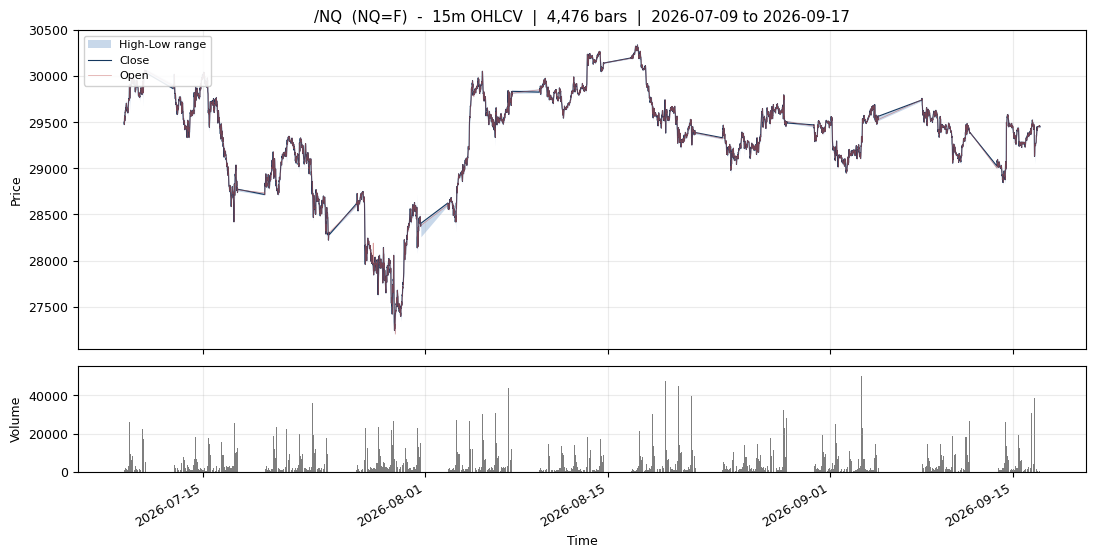

,open,high,low,close,volume
ts,,,,,
2026-07-09 00:00:00-04:00,29506.75,29513.0,29495.00,29500.50,294
2026-07-09 00:15:00-04:00,29499.75,29518.5,29462.50,29474.50,1056
2026-07-09 00:30:00-04:00,29475.00,29539.0,29475.00,29536.25,1682
2026-07-09 00:45:00-04:00,29536.25,29558.5,29521.50,29554.00,964
2026-07-09 01:00:00-04:00,29554.75,29597.0,29508.75,29566.75,2529


In [25]:
# cellblock.2

# /NQ yfinance data (15m) - full OHLCV, maximum available history
nq_15m = load_plot_15m("NQ=F", "/NQ")
nq_15m.head()

/ES  (ES=F)  interval=15m
  bars      : 4,476
  coverage  : 2026-07-09 00:00:00-04:00  ->  2026-09-17 01:00:00-04:00   (70.0 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 7,331.00  -  7,836.50
  volume    : total 63,633,508
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 4,755m (>15m gaps are session breaks/weekends)


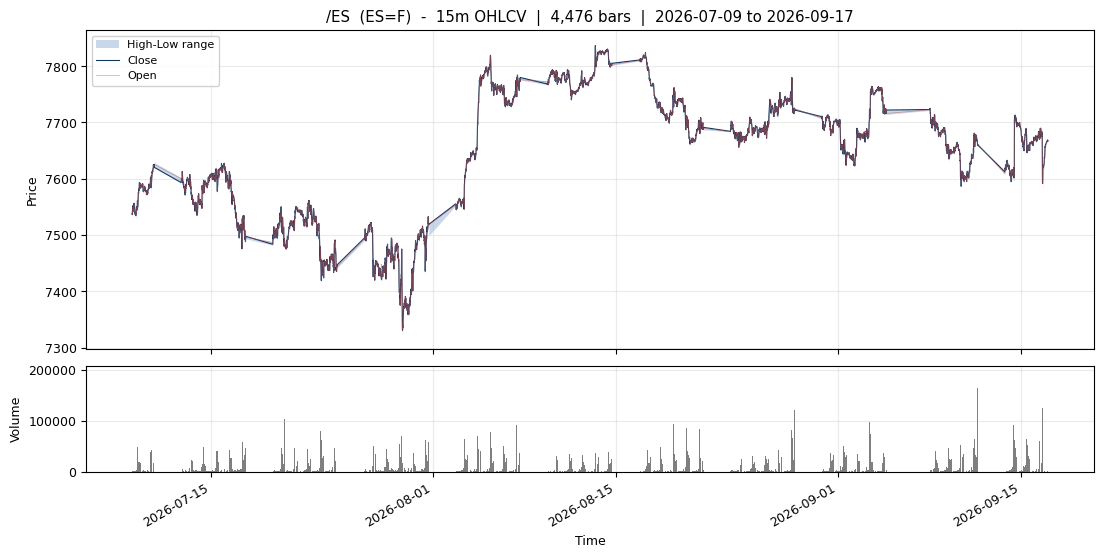

,open,high,low,close,volume
ts,,,,,
2026-07-09 00:00:00-04:00,7539.25,7539.75,7537.75,7538.00,346
2026-07-09 00:15:00-04:00,7538.25,7540.75,7535.00,7536.25,1259
2026-07-09 00:30:00-04:00,7536.50,7544.00,7536.50,7543.50,1765
2026-07-09 00:45:00-04:00,7543.50,7547.00,7541.75,7546.00,1703
2026-07-09 01:00:00-04:00,7546.00,7554.00,7540.75,7549.00,4712


In [26]:
# cellblock.3

# /ES yfinance data (15m) - full OHLCV, maximum available history
es_15m = load_plot_15m("ES=F", "/ES")
es_15m.head()

/RTY  (RTY=F)  interval=15m
  bars      : 4,477
  coverage  : 2026-07-09 00:00:00-04:00  ->  2026-09-17 01:00:00-04:00   (70.0 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 2,858.40  -  3,079.70
  volume    : total 7,650,844
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 4,740m (>15m gaps are session breaks/weekends)


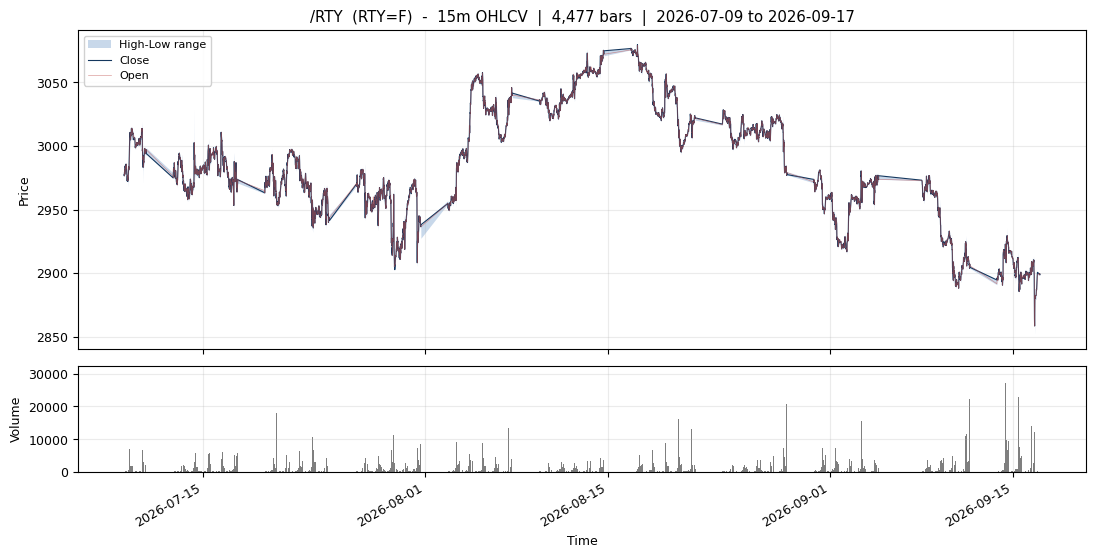

,open,high,low,close,volume
ts,,,,,
2026-07-09 00:00:00-04:00,2977.800049,2977.899902,2977.199951,2977.399902,79
2026-07-09 00:15:00-04:00,2977.399902,2978.600098,2975.699951,2976.500000,111
2026-07-09 00:30:00-04:00,2976.699951,2979.699951,2976.699951,2979.000000,108
2026-07-09 00:45:00-04:00,2979.199951,2980.199951,2977.899902,2979.399902,93
2026-07-09 01:00:00-04:00,2979.399902,2983.699951,2977.000000,2981.300049,645


In [27]:
# cellblock.4

# /RTY yfinance data (15m) - full OHLCV, maximum available history
rty_15m = load_plot_15m("RTY=F", "/RTY")
rty_15m.head()

/YM  (YM=F)  interval=15m
  bars      : 4,478
  coverage  : 2026-07-09 00:00:00-04:00  ->  2026-09-17 01:00:00-04:00   (70.0 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 51,681.00  -  54,874.00
  volume    : total 3,570,575
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 4,755m (>15m gaps are session breaks/weekends)


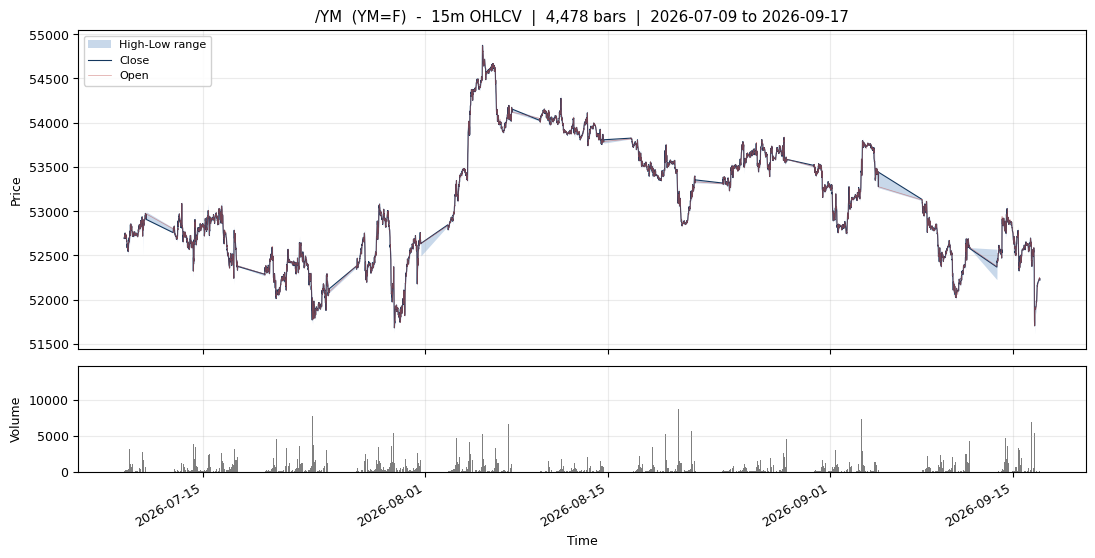

,open,high,low,close,volume
ts,,,,,
2026-07-09 00:00:00-04:00,52695.0,52700.0,52688.0,52695.0,56
2026-07-09 00:15:00-04:00,52696.0,52707.0,52685.0,52690.0,71
2026-07-09 00:30:00-04:00,52694.0,52719.0,52694.0,52712.0,120
2026-07-09 00:45:00-04:00,52714.0,52724.0,52706.0,52718.0,92
2026-07-09 01:00:00-04:00,52719.0,52754.0,52688.0,52731.0,352


In [28]:
# cellblock.5

# /YM yfinance data (15m) - full OHLCV, maximum available history
ym_15m = load_plot_15m("YM=F", "/YM")
ym_15m.head()

BTC  (BTC-USD)  interval=15m
  bars      : 5,685
  coverage  : 2026-07-20 00:00:00+00:00  ->  2026-09-17 05:00:00+00:00   (59.2 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 62,257.03  -  81,759.42
  volume    : total 957,320,200,704
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 15m (>15m gaps are session breaks/weekends)


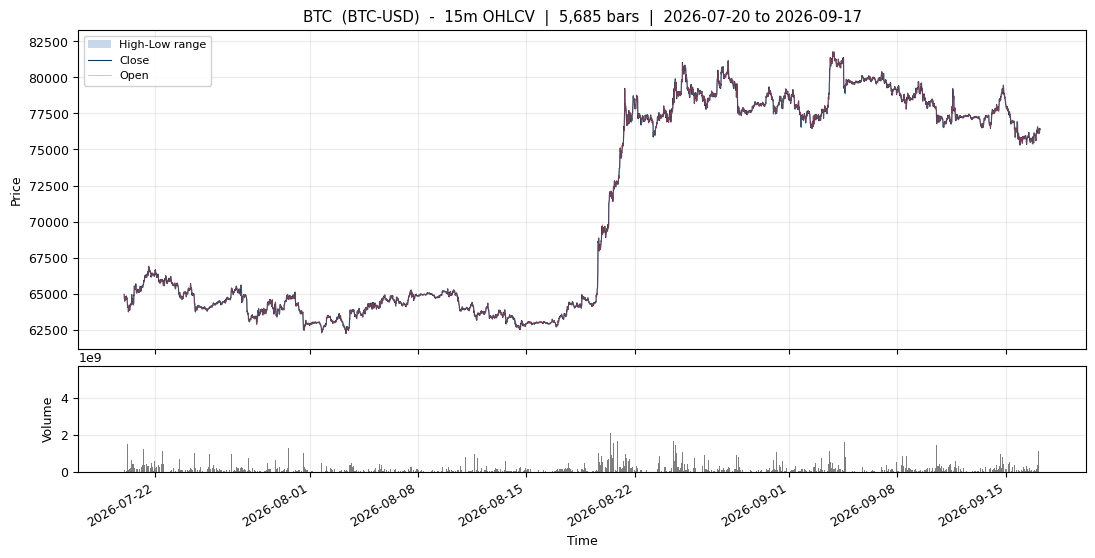

,open,high,low,close,volume
ts,,,,,
2026-07-20 00:00:00+00:00,64685.609375,64990.789062,64528.808594,64972.699219,172272640
2026-07-20 00:15:00+00:00,64968.988281,65040.468750,64752.878906,64825.769531,379905024
2026-07-20 00:30:00+00:00,64819.519531,64893.351562,64736.621094,64760.828125,110635008
2026-07-20 00:45:00+00:00,64754.101562,64754.101562,64364.199219,64503.039062,197901312
2026-07-20 01:00:00+00:00,64510.949219,64959.351562,64453.929688,64757.058594,116081664


In [29]:
# cellblock.6

# BTC yfinance data (15m) - full OHLCV, maximum available history
btc_15m = load_plot_15m("BTC-USD", "BTC")
btc_15m.head()

ETH  (ETH-USD)  interval=15m
  bars      : 5,685
  coverage  : 2026-07-20 00:00:00+00:00  ->  2026-09-17 05:00:00+00:00   (59.2 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 1,829.99  -  2,626.74
  volume    : total 566,902,029,312
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 15m (>15m gaps are session breaks/weekends)


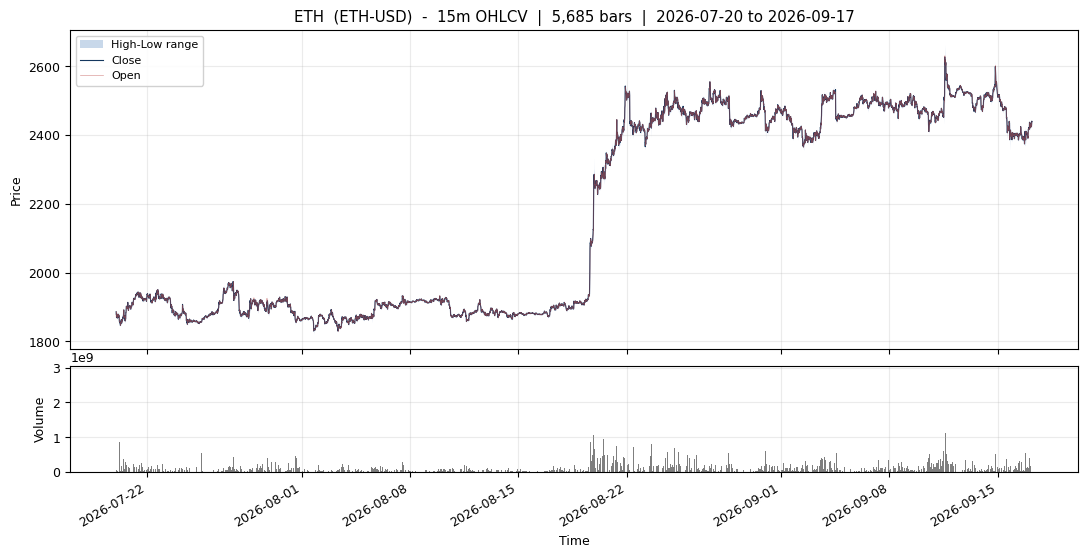

,open,high,low,close,volume
ts,,,,,
2026-07-20 00:00:00+00:00,1871.010010,1888.660034,1865.319946,1886.209961,55717888
2026-07-20 00:15:00+00:00,1886.310059,1890.199951,1875.780029,1878.410034,202898944
2026-07-20 00:30:00+00:00,1879.229980,1883.459961,1875.000000,1879.219971,65798656
2026-07-20 00:45:00+00:00,1878.579956,1878.589966,1861.260010,1870.609985,174651392
2026-07-20 01:00:00+00:00,1870.880005,1887.839966,1869.300049,1878.239990,33713152


In [30]:
# cellblock.7

# ETH yfinance data (15m) - full OHLCV, maximum available history
eth_15m = load_plot_15m("ETH-USD", "ETH")
eth_15m.head()

TSLA  (TSLA)  interval=15m
  bars      : 1,560
  coverage  : 2026-06-23 09:30:00-04:00  ->  2026-09-16 15:45:00-04:00   (85.3 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 297.95  -  431.82
  volume    : total 2,104,591,099
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 5,385m (>15m gaps are session breaks/weekends)


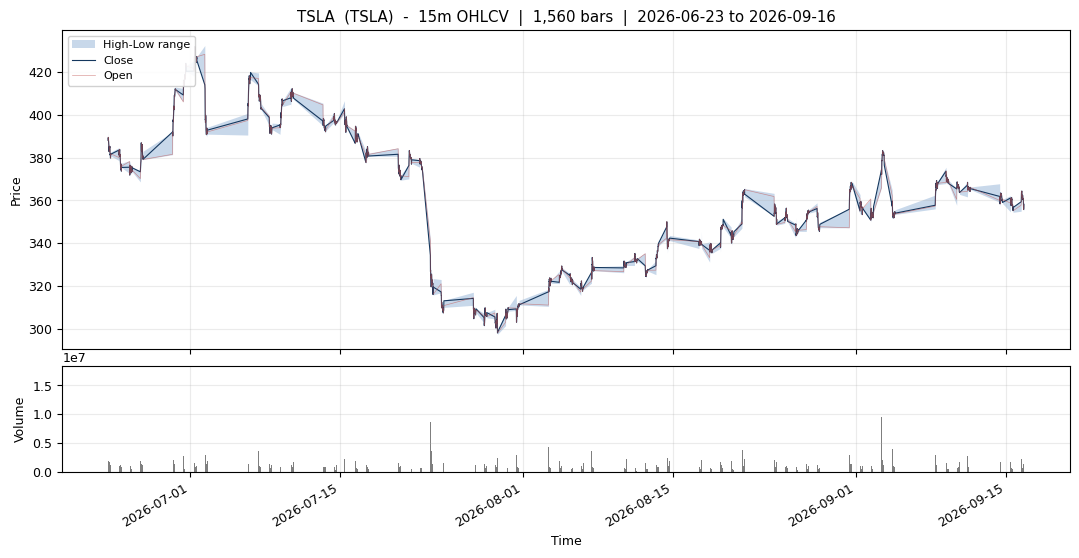

,open,high,low,close,volume
ts,,,,,
2026-06-23 09:30:00-04:00,389.500000,392.320007,387.980011,388.035309,5208377
2026-06-23 09:45:00-04:00,388.109985,390.199890,386.929993,389.290009,2510772
2026-06-23 10:00:00-04:00,389.389893,390.200012,386.350006,388.890015,2250142
2026-06-23 10:15:00-04:00,388.938385,389.169891,386.100006,388.084991,1923990
2026-06-23 10:30:00-04:00,388.075012,389.640015,387.380005,387.630005,1560569


In [31]:
# cellblock.8

# TSLA yfinance data (15m) - full OHLCV, maximum available history
tsla_15m = load_plot_15m("TSLA", "TSLA")
tsla_15m.head()

NVDA  (NVDA)  interval=15m
  bars      : 1,560
  coverage  : 2026-06-23 09:30:00-04:00  ->  2026-09-16 15:45:00-04:00   (85.3 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 190.06  -  234.72
  volume    : total 6,200,684,217
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 5,385m (>15m gaps are session breaks/weekends)


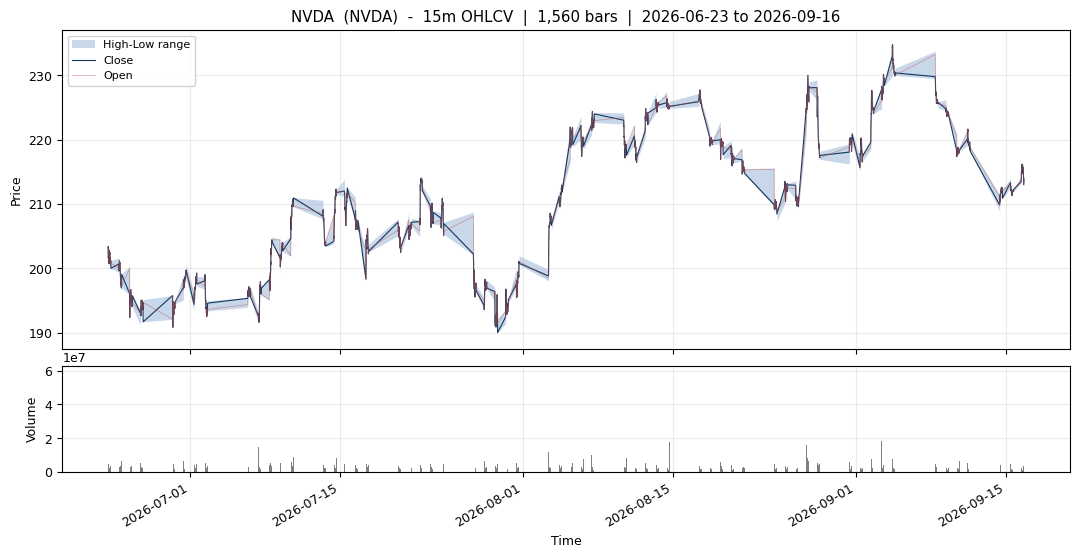

,open,high,low,close,volume
ts,,,,,
2026-06-23 09:30:00-04:00,200.804993,202.509293,200.039993,201.710098,20938804
2026-06-23 09:45:00-04:00,201.690002,203.770004,201.610001,203.410004,6577663
2026-06-23 10:00:00-04:00,203.380005,203.580002,202.789993,203.199997,4692761
2026-06-23 10:15:00-04:00,203.179993,203.399994,202.570007,203.059998,4573453
2026-06-23 10:30:00-04:00,203.092804,203.449997,202.601196,202.800003,3581880


In [32]:
# cellblock.9

# NVDA yfinance data (15m) - full OHLCV, maximum available history
nvda_15m = load_plot_15m("NVDA", "NVDA")
nvda_15m.head()

AAPL  (AAPL)  interval=15m
  bars      : 1,560
  coverage  : 2026-06-23 09:30:00-04:00  ->  2026-09-16 15:45:00-04:00   (85.3 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 274.57  -  343.70
  volume    : total 2,334,314,232
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 5,385m (>15m gaps are session breaks/weekends)


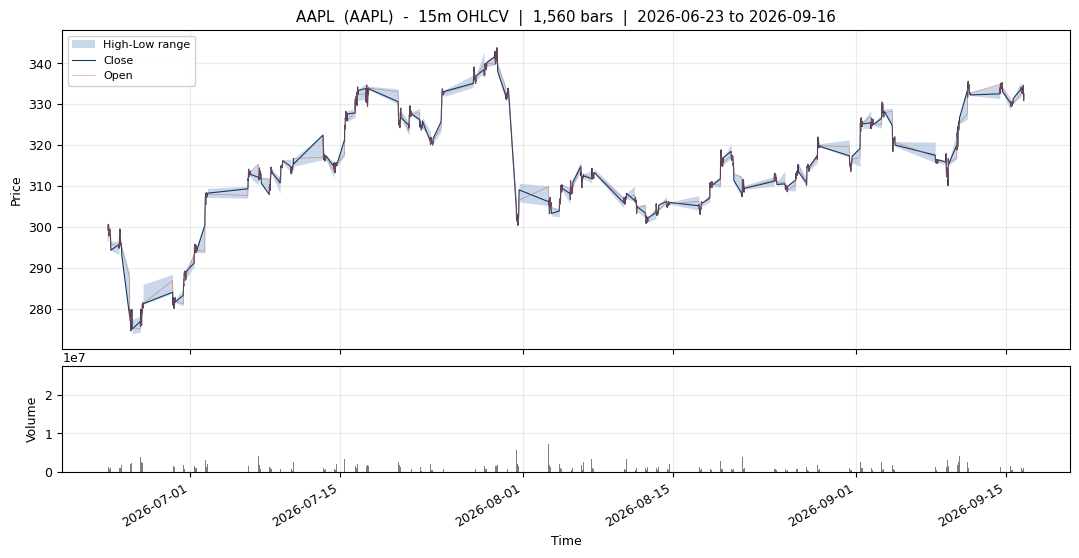

,open,high,low,close,volume
ts,,,,,
2026-06-23 09:30:00-04:00,296.500000,300.577606,296.200012,300.510010,4412573
2026-06-23 09:45:00-04:00,300.470001,301.640015,298.158508,299.109985,1976941
2026-06-23 10:00:00-04:00,299.084991,299.989990,298.795013,299.429993,1473782
2026-06-23 10:15:00-04:00,299.429993,300.559998,298.899994,300.506592,1397185
2026-06-23 10:30:00-04:00,300.519989,300.880005,299.559998,300.350006,1211335


In [33]:
# cellblock.10

# AAPL yfinance data (15m) - full OHLCV, maximum available history
aapl_15m = load_plot_15m("AAPL", "AAPL")
aapl_15m.head()

VIX  (^VIX)  interval=15m
  bars      : 3,084
  coverage  : 2026-06-25 02:15:00-05:00  ->  2026-09-16 15:00:00-05:00   (83.5 calendar days)
  columns   : ['open', 'high', 'low', 'close', 'volume']
  close     : 13.97  -  20.63
  volume    : total 0   [!] all-zero: Yahoo reports no volume for this symbol
  integrity : high<low 0 | OHLC out of range 0 | NaN 0
  bar gaps  : median 15m, max 3,825m (>15m gaps are session breaks/weekends)


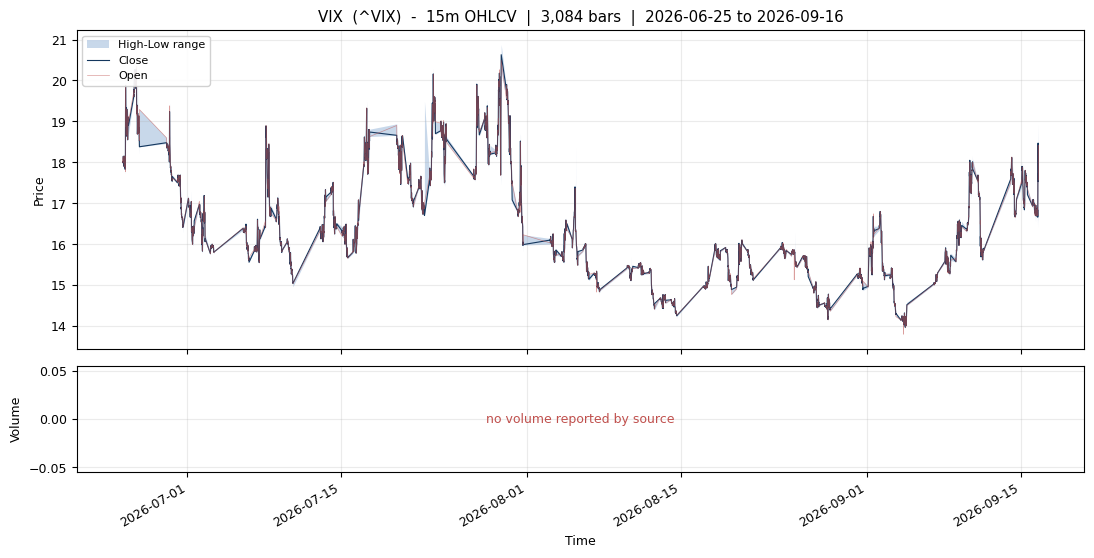

,open,high,low,close,volume
ts,,,,,
2026-06-25 02:15:00-05:00,18.110001,18.110001,17.980000,18.01,0
2026-06-25 02:30:00-05:00,18.020000,18.049999,17.980000,17.99,0
2026-06-25 02:45:00-05:00,17.990000,18.049999,17.990000,18.00,0
2026-06-25 03:00:00-05:00,18.000000,18.040001,17.950001,18.02,0
2026-06-25 03:15:00-05:00,18.040001,18.090000,18.000000,18.01,0


In [34]:
# cellblock.11

# VIX yfinance data (15m) - full OHLCV, maximum available history
vix_15m = load_plot_15m("^VIX", "VIX")
vix_15m.head()

## Module.3
### Re-sampling

Builds every timeframe the strategy needs from the **finest real source available**, plus
maximum-history daily bars for long-horizon work.

| set | source | span | how |
|---|---|---|---|
| `{a}_1d`  | yfinance `interval="1d"`, `period="max"` | 20-37 yrs | fetched |
| `{a}_1m`  | /NQ: local CSV (2010-2026). Others: yfinance 1m, 8-day chunks | /NQ 15 yrs, rest ~30 d | fetched |
| `{a}_3m`  | resampled from `{a}_1m` | = 1m span | aggregated |
| `{a}_5m`  | resampled from `{a}_1m` | = 1m span | aggregated |
| `{a}_15m` | resampled from `{a}_1m` | = 1m span | aggregated |
| `{a}_30m` | resampled from `{a}_1m` | = 1m span | aggregated |
| `{a}_60m` | resampled from `{a}_1m` | = 1m span | aggregated |

---

> **Why the intraday sets are NOT built from the daily bars.**
> Resampling only runs coarse-ward: `1m -> 15m` aggregates trades that actually printed.
> Going `1d -> 1m` is *upsampling* - it would have to invent ~1,380 intrabar prices per day
> that never existed. A backtest fed synthetic intrabar data fills orders at prices nobody
> could have transacted at, which silently manufactures edge. So daily is fetched and kept
> as its own long-history set, and the 1m..60m sets are aggregated **up** from 1-minute bars.
> `resample_ohlcv()` raises on any attempt to upsample.

> **Yahoo's hard limits** (probed, not assumed): `1m` = 8 days per request and ~30 days
> total; `5m/15m/30m` = 60 days; `1h` = 730 days; `1d` = full history. **`3m` is not a
> valid Yahoo interval at all** - it can only ever come from resampling 1m.

> **`{a}_15m` is rebuilt here** from the 1m source and supersedes the native 15m pull from
> Module.2. For /NQ this is a large upgrade: 366k bars back to 2010 instead of Yahoo's
> 60-day window.

> **Known source defect:** Yahoo's *daily* futures bars include some where the open or
> close falls outside that bar's high/low range - /YM 29 bars (0.47%, worst 450 pts, as
> recent as 2025-03-19), /NQ 24, /ES 10; /RTY and the equities are clean. `fetch_daily`
> prints a warning but does **not** repair them, because silently rewriting prices is
> worse than knowing they are wrong. Filter them before using daily bars for fills.

> **Bar convention:** bars are left-labelled (stamped at the bar's *open*), matching both the
> databento CSV and Yahoo. A bar stamped `09:30` on the 15m set covers `[09:30, 09:45)` and
> is therefore only complete at `09:45` - **do not let a signal read it at 09:30.**


In [ ]:
# cellblock.1

# resampling engine
import time

AGG = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
TIMEFRAMES = {"1m": "1min", "3m": "3min", "5m": "5min",
               "15m": "15min", "30m": "30min", "60m": "60min"}


def resample_ohlcv(df, tf, src_step="1min", drop_partial=True, label=""):
    """Aggregate an OHLCV frame up to timeframe `tf`.

    Bars are left-labelled/left-closed, so a bar is stamped at its OPEN and only
    becomes complete one `tf` later. Empty bins (weekends, halts, session breaks)
    are dropped rather than forward-filled - a forward-filled bar is a bar that
    never traded. Upsampling is refused outright.
    """
    freq = TIMEFRAMES.get(tf, tf)
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{label}: index must be a DatetimeIndex, got {type(df.index).__name__}")
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()

    src = pd.Timedelta(src_step)
    if pd.Timedelta(freq) < src:
        raise ValueError(
            f"{label}: refusing to resample a {src_step} source UP to {tf}. "
            "Upsampling fabricates bars that never traded.")

    g     = df.resample(freq, label="left", closed="left")
    out   = g.agg(AGG)
    n_src = g.size().reindex(out.index)
    out, n_src = out[n_src > 0], n_src[n_src > 0]        # drop empty bins

    # a trailing bin the source never reached is incomplete -> its "close" is fake
    dropped_partial = False
    if drop_partial and len(out):
        if df.index[-1] + src < out.index[-1] + pd.Timedelta(freq):
            out, n_src, dropped_partial = out.iloc[:-1], n_src.iloc[:-1], True

    out["volume"] = out["volume"].fillna(0)
    out.index.name = "ts"
    out.attrs.update(tf=tf, src_step=src_step, label=label,
                     n_src=n_src, dropped_partial=dropped_partial)
    return out


def describe_bars(df, label, tf):
    """Print coverage + integrity checks for a resampled set. Returns it unchanged."""
    n_src   = df.attrs.get("n_src")
    span    = (df.index[-1] - df.index[0]).total_seconds() / 86400
    bad_rng = int((~((df["high"] >= df[["open", "close"]].max(axis=1) - 1e-6) &
                     (df["low"]  <= df[["open", "close"]].min(axis=1) + 1e-6))).sum())
    print(f"{label}  {tf}")
    print(f"  bars      : {len(df):,}")
    print(f"  coverage  : {df.index[0]}  ->  {df.index[-1]}   ({span:,.1f} days)")
    print(f"  close     : {df['close'].min():,.2f} - {df['close'].max():,.2f}")
    print(f"  volume    : {df['volume'].sum():,.0f}"
          + ("   [!] all-zero: source reports no volume" if df["volume"].sum() == 0 else ""))
    print(f"  integrity : high<low {int((df['high'] < df['low']).sum())} | "
          f"OHLC out of range {bad_rng} | NaN {int(df.isna().sum().sum())} | "
          f"dup ts {int(df.index.duplicated().sum())}")
    if n_src is not None and len(n_src):
        full = int(pd.Timedelta(TIMEFRAMES[tf]) / pd.Timedelta(df.attrs["src_step"]))
        print(f"  bin fill  : median {n_src.median():.0f}/{full} source bars, "
              f"min {n_src.min():.0f}, thin(<50%) {int((n_src < full * 0.5).sum()):,}")
    if df.attrs.get("dropped_partial"):
        print(f"  [note] trailing incomplete {tf} bar dropped")
    return df


In [ ]:
# cellblock.2

# fetchers: maximum-history daily, and chunked 1m
def _clean(raw, label, ticker):
    """Flatten yfinance output to a sorted, deduped, tz-aware OHLCV frame."""
    if raw is None or len(raw) == 0:
        raise RuntimeError(f"{label} ({ticker}): yfinance returned no rows")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(-1)
    df = raw.rename(columns=str.lower)
    missing = [c for c in OHLCV if c not in df.columns]
    if missing:
        raise RuntimeError(f"{label} ({ticker}): missing columns {missing}")
    df = df[OHLCV].copy()
    df = df[~df.index.duplicated(keep="last")].sort_index()
    df = df.dropna(subset=["open", "high", "low", "close"])
    df["volume"] = df["volume"].fillna(0)
    df.index.name = "ts"
    df.columns.name = None
    return df


def fetch_daily(ticker, label):
    """Maximum available daily history. This is the only set with real depth."""
    df = _clean(yf.download(ticker, period="max", interval="1d", auto_adjust=False,
                            progress=False, threads=False), label, ticker)
    print(f"{label:5} ({ticker:8}) 1d  {len(df):>9,} bars  "
          f"{df.index[0]:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d}  "
          f"({(df.index[-1] - df.index[0]).days / 365.25:5.1f} yrs)")

    # Yahoo's daily futures bars contain bars whose open/close sit OUTSIDE the
    # high/low range. Reported, never silently repaired - a backtest that assumes
    # low <= open,close <= high would compute impossible fills on these dates.
    bad = ~((df["high"] >= df[["open", "close"]].max(axis=1) - 1e-6) &
            (df["low"]  <= df[["open", "close"]].min(axis=1) + 1e-6))
    if bad.any():
        print(f"      [!] {int(bad.sum())} bar(s) with OHLC outside the high/low range "
              f"({100 * bad.mean():.2f}%) - source defect, NOT repaired. "
              f"Last: {df.index[bad][-1]:%Y-%m-%d}. "
              f"Filter with df[~bad] before using these for fills.")
    return df


YF_1M_LOOKBACK_DAYS = 30      # Yahoo keeps roughly this much 1m history
YF_1M_CHUNK_DAYS    = 7       # and hands back at most 8 days per request


def fetch_1m(ticker, label, lookback=YF_1M_LOOKBACK_DAYS,
             chunk=YF_1M_CHUNK_DAYS, pause=0.4):
    """Walk Yahoo's 1m window in chunks, since it caps each request at 8 days."""
    end         = pd.Timestamp.utcnow().normalize() + pd.Timedelta(days=1)
    start_floor = end - pd.Timedelta(days=lookback)
    parts, fails, win_end = [], 0, end

    while win_end > start_floor:
        win_start = max(win_end - pd.Timedelta(days=chunk), start_floor)
        try:
            raw = yf.download(ticker, start=win_start.date(), end=win_end.date(),
                              interval="1m", auto_adjust=False, progress=False,
                              threads=False)
            if raw is not None and len(raw):
                parts.append(_clean(raw, label, ticker))
        except Exception:
            fails += 1
        win_end = win_start
        time.sleep(pause)

    if not parts:
        raise RuntimeError(f"{label} ({ticker}): no 1m data in the last {lookback}d")
    df = pd.concat(parts).sort_index()
    df = df[~df.index.duplicated(keep="last")]
    print(f"{label:5} ({ticker:8}) 1m  {len(df):>9,} bars  "
          f"{df.index[0]:%Y-%m-%d %H:%M} -> {df.index[-1]:%Y-%m-%d %H:%M}"
          + (f"   [{fails} chunk(s) failed]" if fails else ""))
    return df


### 3.1 - Daily bars, maximum available history
One cellblock per asset. This is the deepest data in the system (20-37 years) and the only
set long enough for regime analysis or walk-forward validation across cycles.

In [ ]:
# cellblock.3

# /NQ daily - maximum available history
nq_1d = fetch_daily("NQ=F", "/NQ")
nq_1d.head()


In [ ]:
# cellblock.4

# /ES daily - maximum available history
es_1d = fetch_daily("ES=F", "/ES")
es_1d.head()


In [ ]:
# cellblock.5

# /RTY daily - maximum available history
rty_1d = fetch_daily("RTY=F", "/RTY")
rty_1d.head()


In [ ]:
# cellblock.6

# /YM daily - maximum available history
ym_1d = fetch_daily("YM=F", "/YM")
ym_1d.head()


In [ ]:
# cellblock.7

# BTC daily - maximum available history
btc_1d = fetch_daily("BTC-USD", "BTC")
btc_1d.head()


In [ ]:
# cellblock.8

# ETH daily - maximum available history
eth_1d = fetch_daily("ETH-USD", "ETH")
eth_1d.head()


In [ ]:
# cellblock.9

# TSLA daily - maximum available history
tsla_1d = fetch_daily("TSLA", "TSLA")
tsla_1d.head()


In [ ]:
# cellblock.10

# NVDA daily - maximum available history
nvda_1d = fetch_daily("NVDA", "NVDA")
nvda_1d.head()


In [ ]:
# cellblock.11

# AAPL daily - maximum available history
aapl_1d = fetch_daily("AAPL", "AAPL")
aapl_1d.head()


In [ ]:
# cellblock.12

# VIX daily - maximum available history
vix_1d = fetch_daily("^VIX", "VIX")
vix_1d.head()


### 3.2 - 1m base bars
Every intraday set below is aggregated from these. /NQ uses the local continuous
front-month CSV built in Module.2 cellblock.1 (5.3M bars, 2010-2026); the other nine come
from Yahoo's 1m window, which only reaches back ~30 days.

In [ ]:
# cellblock.13

# /NQ 1m base - the LOCAL continuous front-month from Module.2 cellblock.1,
# not Yahoo's 30-day 1m window. 15 years of depth instead of 30 days.
if "nq_1m" not in globals():
    raise RuntimeError("run Module.2 cellblock.1 first - it builds nq_1m from the local CSV")

print(f"/NQ   (local CSV) 1m  {len(nq_1m):>9,} bars  "
      f"{nq_1m.index[0]:%Y-%m-%d %H:%M} -> {nq_1m.index[-1]:%Y-%m-%d %H:%M}  "
      f"({(nq_1m.index[-1] - nq_1m.index[0]).days / 365.25:5.1f} yrs)")
nq_1m.head()


In [ ]:
# cellblock.14

# /ES 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
es_1m = fetch_1m("ES=F", "/ES")
es_1m.head()


In [ ]:
# cellblock.15

# /RTY 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
rty_1m = fetch_1m("RTY=F", "/RTY")
rty_1m.head()


In [ ]:
# cellblock.16

# /YM 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
ym_1m = fetch_1m("YM=F", "/YM")
ym_1m.head()


In [ ]:
# cellblock.17

# BTC 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
btc_1m = fetch_1m("BTC-USD", "BTC")
btc_1m.head()


In [ ]:
# cellblock.18

# ETH 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
eth_1m = fetch_1m("ETH-USD", "ETH")
eth_1m.head()


In [ ]:
# cellblock.19

# TSLA 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
tsla_1m = fetch_1m("TSLA", "TSLA")
tsla_1m.head()


In [ ]:
# cellblock.20

# NVDA 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
nvda_1m = fetch_1m("NVDA", "NVDA")
nvda_1m.head()


In [ ]:
# cellblock.21

# AAPL 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
aapl_1m = fetch_1m("AAPL", "AAPL")
aapl_1m.head()


In [ ]:
# cellblock.22

# VIX 1m base (yfinance, chunked - Yahoo caps 1m at ~30 days)
vix_1m = fetch_1m("^VIX", "VIX")
vix_1m.head()


### 3.3 - Resampled sets: 3m, 5m, 15m, 30m, 60m
One cellblock per asset per timeframe, each aggregated from that asset's 1m base.
`3m` exists only here - Yahoo does not serve it at any period.

**/NQ** - resampled from `nq_1m` (local 1m, 2010-2026)

In [ ]:
# cellblock.23

# /NQ  3m  - resampled from nq_1m
nq_3m = resample_ohlcv(nq_1m, "3m", label="/NQ")
describe_bars(nq_3m, "/NQ", "3m")
nq_3m.head()


In [ ]:
# cellblock.24

# /NQ  5m  - resampled from nq_1m
nq_5m = resample_ohlcv(nq_1m, "5m", label="/NQ")
describe_bars(nq_5m, "/NQ", "5m")
nq_5m.head()


In [ ]:
# cellblock.25

# /NQ  15m  - resampled from nq_1m
nq_15m = resample_ohlcv(nq_1m, "15m", label="/NQ")
describe_bars(nq_15m, "/NQ", "15m")
nq_15m.head()


In [ ]:
# cellblock.26

# /NQ  30m  - resampled from nq_1m
nq_30m = resample_ohlcv(nq_1m, "30m", label="/NQ")
describe_bars(nq_30m, "/NQ", "30m")
nq_30m.head()


In [ ]:
# cellblock.27

# /NQ  60m  - resampled from nq_1m
nq_60m = resample_ohlcv(nq_1m, "60m", label="/NQ")
describe_bars(nq_60m, "/NQ", "60m")
nq_60m.head()


**/ES** - resampled from `es_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.28

# /ES  3m  - resampled from es_1m
es_3m = resample_ohlcv(es_1m, "3m", label="/ES")
describe_bars(es_3m, "/ES", "3m")
es_3m.head()


In [ ]:
# cellblock.29

# /ES  5m  - resampled from es_1m
es_5m = resample_ohlcv(es_1m, "5m", label="/ES")
describe_bars(es_5m, "/ES", "5m")
es_5m.head()


In [ ]:
# cellblock.30

# /ES  15m  - resampled from es_1m
es_15m = resample_ohlcv(es_1m, "15m", label="/ES")
describe_bars(es_15m, "/ES", "15m")
es_15m.head()


In [ ]:
# cellblock.31

# /ES  30m  - resampled from es_1m
es_30m = resample_ohlcv(es_1m, "30m", label="/ES")
describe_bars(es_30m, "/ES", "30m")
es_30m.head()


In [ ]:
# cellblock.32

# /ES  60m  - resampled from es_1m
es_60m = resample_ohlcv(es_1m, "60m", label="/ES")
describe_bars(es_60m, "/ES", "60m")
es_60m.head()


**/RTY** - resampled from `rty_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.33

# /RTY  3m  - resampled from rty_1m
rty_3m = resample_ohlcv(rty_1m, "3m", label="/RTY")
describe_bars(rty_3m, "/RTY", "3m")
rty_3m.head()


In [ ]:
# cellblock.34

# /RTY  5m  - resampled from rty_1m
rty_5m = resample_ohlcv(rty_1m, "5m", label="/RTY")
describe_bars(rty_5m, "/RTY", "5m")
rty_5m.head()


In [ ]:
# cellblock.35

# /RTY  15m  - resampled from rty_1m
rty_15m = resample_ohlcv(rty_1m, "15m", label="/RTY")
describe_bars(rty_15m, "/RTY", "15m")
rty_15m.head()


In [ ]:
# cellblock.36

# /RTY  30m  - resampled from rty_1m
rty_30m = resample_ohlcv(rty_1m, "30m", label="/RTY")
describe_bars(rty_30m, "/RTY", "30m")
rty_30m.head()


In [ ]:
# cellblock.37

# /RTY  60m  - resampled from rty_1m
rty_60m = resample_ohlcv(rty_1m, "60m", label="/RTY")
describe_bars(rty_60m, "/RTY", "60m")
rty_60m.head()


**/YM** - resampled from `ym_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.38

# /YM  3m  - resampled from ym_1m
ym_3m = resample_ohlcv(ym_1m, "3m", label="/YM")
describe_bars(ym_3m, "/YM", "3m")
ym_3m.head()


In [ ]:
# cellblock.39

# /YM  5m  - resampled from ym_1m
ym_5m = resample_ohlcv(ym_1m, "5m", label="/YM")
describe_bars(ym_5m, "/YM", "5m")
ym_5m.head()


In [ ]:
# cellblock.40

# /YM  15m  - resampled from ym_1m
ym_15m = resample_ohlcv(ym_1m, "15m", label="/YM")
describe_bars(ym_15m, "/YM", "15m")
ym_15m.head()


In [ ]:
# cellblock.41

# /YM  30m  - resampled from ym_1m
ym_30m = resample_ohlcv(ym_1m, "30m", label="/YM")
describe_bars(ym_30m, "/YM", "30m")
ym_30m.head()


In [ ]:
# cellblock.42

# /YM  60m  - resampled from ym_1m
ym_60m = resample_ohlcv(ym_1m, "60m", label="/YM")
describe_bars(ym_60m, "/YM", "60m")
ym_60m.head()


**BTC** - resampled from `btc_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.43

# BTC  3m  - resampled from btc_1m
btc_3m = resample_ohlcv(btc_1m, "3m", label="BTC")
describe_bars(btc_3m, "BTC", "3m")
btc_3m.head()


In [ ]:
# cellblock.44

# BTC  5m  - resampled from btc_1m
btc_5m = resample_ohlcv(btc_1m, "5m", label="BTC")
describe_bars(btc_5m, "BTC", "5m")
btc_5m.head()


In [ ]:
# cellblock.45

# BTC  15m  - resampled from btc_1m
btc_15m = resample_ohlcv(btc_1m, "15m", label="BTC")
describe_bars(btc_15m, "BTC", "15m")
btc_15m.head()


In [ ]:
# cellblock.46

# BTC  30m  - resampled from btc_1m
btc_30m = resample_ohlcv(btc_1m, "30m", label="BTC")
describe_bars(btc_30m, "BTC", "30m")
btc_30m.head()


In [ ]:
# cellblock.47

# BTC  60m  - resampled from btc_1m
btc_60m = resample_ohlcv(btc_1m, "60m", label="BTC")
describe_bars(btc_60m, "BTC", "60m")
btc_60m.head()


**ETH** - resampled from `eth_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.48

# ETH  3m  - resampled from eth_1m
eth_3m = resample_ohlcv(eth_1m, "3m", label="ETH")
describe_bars(eth_3m, "ETH", "3m")
eth_3m.head()


In [ ]:
# cellblock.49

# ETH  5m  - resampled from eth_1m
eth_5m = resample_ohlcv(eth_1m, "5m", label="ETH")
describe_bars(eth_5m, "ETH", "5m")
eth_5m.head()


In [ ]:
# cellblock.50

# ETH  15m  - resampled from eth_1m
eth_15m = resample_ohlcv(eth_1m, "15m", label="ETH")
describe_bars(eth_15m, "ETH", "15m")
eth_15m.head()


In [ ]:
# cellblock.51

# ETH  30m  - resampled from eth_1m
eth_30m = resample_ohlcv(eth_1m, "30m", label="ETH")
describe_bars(eth_30m, "ETH", "30m")
eth_30m.head()


In [ ]:
# cellblock.52

# ETH  60m  - resampled from eth_1m
eth_60m = resample_ohlcv(eth_1m, "60m", label="ETH")
describe_bars(eth_60m, "ETH", "60m")
eth_60m.head()


**TSLA** - resampled from `tsla_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.53

# TSLA  3m  - resampled from tsla_1m
tsla_3m = resample_ohlcv(tsla_1m, "3m", label="TSLA")
describe_bars(tsla_3m, "TSLA", "3m")
tsla_3m.head()


In [ ]:
# cellblock.54

# TSLA  5m  - resampled from tsla_1m
tsla_5m = resample_ohlcv(tsla_1m, "5m", label="TSLA")
describe_bars(tsla_5m, "TSLA", "5m")
tsla_5m.head()


In [ ]:
# cellblock.55

# TSLA  15m  - resampled from tsla_1m
tsla_15m = resample_ohlcv(tsla_1m, "15m", label="TSLA")
describe_bars(tsla_15m, "TSLA", "15m")
tsla_15m.head()


In [ ]:
# cellblock.56

# TSLA  30m  - resampled from tsla_1m
tsla_30m = resample_ohlcv(tsla_1m, "30m", label="TSLA")
describe_bars(tsla_30m, "TSLA", "30m")
tsla_30m.head()


In [ ]:
# cellblock.57

# TSLA  60m  - resampled from tsla_1m
tsla_60m = resample_ohlcv(tsla_1m, "60m", label="TSLA")
describe_bars(tsla_60m, "TSLA", "60m")
tsla_60m.head()


**NVDA** - resampled from `nvda_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.58

# NVDA  3m  - resampled from nvda_1m
nvda_3m = resample_ohlcv(nvda_1m, "3m", label="NVDA")
describe_bars(nvda_3m, "NVDA", "3m")
nvda_3m.head()


In [ ]:
# cellblock.59

# NVDA  5m  - resampled from nvda_1m
nvda_5m = resample_ohlcv(nvda_1m, "5m", label="NVDA")
describe_bars(nvda_5m, "NVDA", "5m")
nvda_5m.head()


In [ ]:
# cellblock.60

# NVDA  15m  - resampled from nvda_1m
nvda_15m = resample_ohlcv(nvda_1m, "15m", label="NVDA")
describe_bars(nvda_15m, "NVDA", "15m")
nvda_15m.head()


In [ ]:
# cellblock.61

# NVDA  30m  - resampled from nvda_1m
nvda_30m = resample_ohlcv(nvda_1m, "30m", label="NVDA")
describe_bars(nvda_30m, "NVDA", "30m")
nvda_30m.head()


In [ ]:
# cellblock.62

# NVDA  60m  - resampled from nvda_1m
nvda_60m = resample_ohlcv(nvda_1m, "60m", label="NVDA")
describe_bars(nvda_60m, "NVDA", "60m")
nvda_60m.head()


**AAPL** - resampled from `aapl_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.63

# AAPL  3m  - resampled from aapl_1m
aapl_3m = resample_ohlcv(aapl_1m, "3m", label="AAPL")
describe_bars(aapl_3m, "AAPL", "3m")
aapl_3m.head()


In [ ]:
# cellblock.64

# AAPL  5m  - resampled from aapl_1m
aapl_5m = resample_ohlcv(aapl_1m, "5m", label="AAPL")
describe_bars(aapl_5m, "AAPL", "5m")
aapl_5m.head()


In [ ]:
# cellblock.65

# AAPL  15m  - resampled from aapl_1m
aapl_15m = resample_ohlcv(aapl_1m, "15m", label="AAPL")
describe_bars(aapl_15m, "AAPL", "15m")
aapl_15m.head()


In [ ]:
# cellblock.66

# AAPL  30m  - resampled from aapl_1m
aapl_30m = resample_ohlcv(aapl_1m, "30m", label="AAPL")
describe_bars(aapl_30m, "AAPL", "30m")
aapl_30m.head()


In [ ]:
# cellblock.67

# AAPL  60m  - resampled from aapl_1m
aapl_60m = resample_ohlcv(aapl_1m, "60m", label="AAPL")
describe_bars(aapl_60m, "AAPL", "60m")
aapl_60m.head()


**VIX** - resampled from `vix_1m` (yfinance 1m, ~30d)

In [ ]:
# cellblock.68

# VIX  3m  - resampled from vix_1m
vix_3m = resample_ohlcv(vix_1m, "3m", label="VIX")
describe_bars(vix_3m, "VIX", "3m")
vix_3m.head()


In [ ]:
# cellblock.69

# VIX  5m  - resampled from vix_1m
vix_5m = resample_ohlcv(vix_1m, "5m", label="VIX")
describe_bars(vix_5m, "VIX", "5m")
vix_5m.head()


In [ ]:
# cellblock.70

# VIX  15m  - resampled from vix_1m
vix_15m = resample_ohlcv(vix_1m, "15m", label="VIX")
describe_bars(vix_15m, "VIX", "15m")
vix_15m.head()


In [ ]:
# cellblock.71

# VIX  30m  - resampled from vix_1m
vix_30m = resample_ohlcv(vix_1m, "30m", label="VIX")
describe_bars(vix_30m, "VIX", "30m")
vix_30m.head()


In [ ]:
# cellblock.72

# VIX  60m  - resampled from vix_1m
vix_60m = resample_ohlcv(vix_1m, "60m", label="VIX")
describe_bars(vix_60m, "VIX", "60m")
vix_60m.head()


In [ ]:
# cellblock.73

# Module.3 registry + cross-checks
DATASETS = {}
for _v, _lab, _tkr in [("nq","/NQ","NQ=F"), ("es","/ES","ES=F"), ("rty","/RTY","RTY=F"), ("ym","/YM","YM=F"), ("btc","BTC","BTC-USD"), ("eth","ETH","ETH-USD"), ("tsla","TSLA","TSLA"), ("nvda","NVDA","NVDA"), ("aapl","AAPL","AAPL"), ("vix","VIX","^VIX")]:
    DATASETS[_lab] = {tf: globals()[f"{_v}_{tf}"]
                      for tf in ["1d", "1m", "3m", "5m", "15m", "30m", "60m"]
                      if f"{_v}_{tf}" in globals()}

print(f"{'asset':6} {'1d':>9} {'1m':>10} {'3m':>10} {'5m':>10} "
      f"{'15m':>9} {'30m':>9} {'60m':>9}")
print("-" * 82)
for _lab, _sets in DATASETS.items():
    print(f"{_lab:6}" + "".join(
        f"{len(_sets[tf]):>10,}" if tf in _sets else f"{'-':>10}"
        for tf in ["1d", "1m", "3m", "5m", "15m", "30m", "60m"]))

# volume must survive aggregation exactly, and the span must not change
print("\nconservation checks (1m -> each timeframe):")
for _lab, _sets in DATASETS.items():
    if "1m" not in _sets:
        continue
    _base = _sets["1m"]["volume"].sum()
    _bad = [tf for tf in ["3m", "5m", "15m", "30m", "60m"]
            if tf in _sets and not _sets[tf].attrs.get("dropped_partial")
            and _sets[tf]["volume"].sum() != _base]
    print(f"  {_lab:6} volume conserved: {'FAIL -> ' + str(_bad) if _bad else 'OK'}"
          f"   (trailing partial bars excluded where dropped)")


## Module.4
### Strategy importing